In [1]:
# ----- Setup -----
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import random
import time


# ----- Set experiment ID to test -----
exp_id = 17  # <- Change this value to test a different model  #-------

# ----- Load Metadata from Training -----
with open("results_metadata.json", "r") as f:
    metadata = pd.read_json(f)

row = metadata[metadata["experiment_id"] == exp_id].iloc[0]  #-------
PRED_LEN = int(row["pred_len"])  #-------

# ----- Load Zara 2 Data -----
df = pd.read_csv("converted_zara_1.csv")


SEQ_LEN = 8

# ----- Dataset Definition -----
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        obs, fut = self.trajectories[idx]
        return torch.tensor(obs, dtype=torch.float32), torch.tensor(fut, dtype=torch.float32)

# ----- Rebuild Zara 2 Trajectories -----
trajectories = []
for pid, person_df in df.groupby("person_id"):
    person_df = person_df.sort_values("frame_id")
    coords = person_df[['x', 'y']].values
    for i in range(len(coords) - SEQ_LEN - PRED_LEN):
        obs = coords[i:i+SEQ_LEN]
        fut = coords[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN]
        trajectories.append((obs, fut))

data_loader = DataLoader(TrajectoryDataset(trajectories), batch_size=64, shuffle=False)

# ----- LSTM Model Definition -----
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_len, num_layers, dropout, bidirectional):
        super(LSTMModel, self).__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional
        )
        direction_multiplier = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction_multiplier, 2 * output_len)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        hn = torch.cat((hn[-2], hn[-1]), dim=1) if self.bidirectional else hn[-1]
        out = self.fc(hn)
        return out.view(-1, self.fc.out_features // 2, 2)


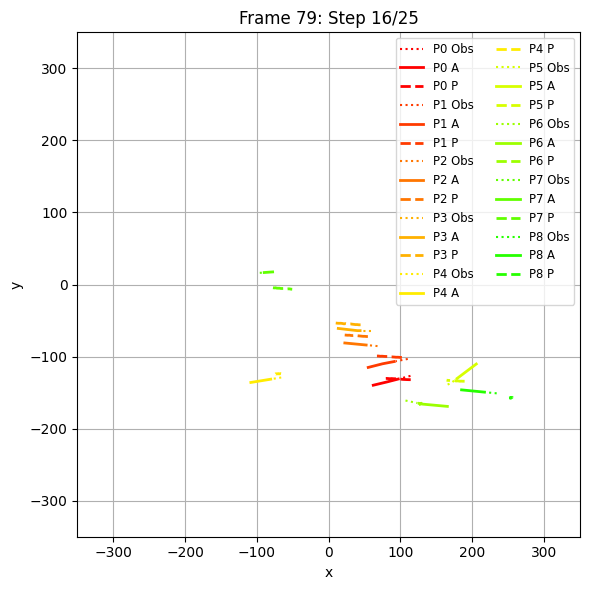

In [ ]:
# ----- Evaluate Specific Model on Zara 2 -----
results = []
criterion = nn.MSELoss()

model_path = f"lstm_zara_exp_{exp_id}.pth"  #-------

if os.path.exists(model_path):  #-------
    model = LSTMModel(
        input_size=2,
        hidden_size=int(row["hidden_size"]),
        output_len=int(row["pred_len"]),
        num_layers=int(row["num_layers"]),
        dropout=float(row["dropout"]),
        bidirectional=bool(row["bidirectional"])
    )
    model.load_state_dict(torch.load(model_path))  #-------
    model.eval()

  # ... (keep all previous code unchanged until this block) ...

from IPython.display import clear_output  #-------
import matplotlib.cm as cm  #-------

# ... (keep all previous code unchanged until this block) ...

# ----- Updated Dataset with Metadata -----  #-------
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        item = self.trajectories[idx]
        obs = torch.tensor(item['obs'], dtype=torch.float32)
        fut = torch.tensor(item['fut'], dtype=torch.float32)
        return obs, fut, item['person_id'], item['start_frame']  #-------

# ----- Rebuild Zara 2 Trajectories with Metadata -----  #-------
trajectories = []
for pid, person_df in df.groupby("person_id"):
    person_df = person_df.sort_values("frame_id")
    coords = person_df[['x', 'y']].values
    frames = person_df['frame_id'].values
    for i in range(len(coords) - SEQ_LEN - PRED_LEN):
        obs = coords[i:i+SEQ_LEN]
        fut = coords[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN]
        start_frame = frames[i+SEQ_LEN]  # first frame of the future trajectory  #-------
        trajectories.append({
            "obs": obs,
            "fut": fut,
            "person_id": pid,  #-------
            "start_frame": int(start_frame)  #-------
        })

# ----- Use Updated Dataset -----  #-------
data_loader = DataLoader(TrajectoryDataset(trajectories), batch_size=64, shuffle=False)

total_loss = 0
with torch.no_grad():
    all_preds = []
    all_futs = []
    all_obs = []
    all_pids = []
    all_frames = []

    for i, batch in enumerate(data_loader):
        obs, fut, pids, frames = batch  #-------
        pred = model(obs)
        loss = criterion(pred, fut)
        total_loss += loss.item()

        all_preds.append(pred)
        all_futs.append(fut)
        all_obs.append(obs)
        all_pids.extend(pids.numpy())
        all_frames.extend(frames.numpy())

    preds = torch.cat(all_preds)
    futs = torch.cat(all_futs)
    obs_all = torch.cat(all_obs)

    # Group by shared frame_id
    frame_to_indices = {}
    for idx, frame in enumerate(all_frames):
        frame_to_indices.setdefault(frame, []).append(idx)

    color_map = cm.get_cmap('hsv', 512)

    for frame_id, indices in sorted(frame_to_indices.items()):
        for t in range(PRED_LEN):
            clear_output(wait=True)
            plt.figure(figsize=(6, 6))

            for cidx, idx in enumerate(indices):
                color = color_map(cidx * 20 % 512)  # assign unique color per person
                actual = futs[idx].numpy()
                predicted = preds[idx].numpy()
                observed = obs_all[idx].numpy()
                pid = all_pids[idx]

                plt.plot(observed[:, 0], observed[:, 1], linestyle=':', color=color, linewidth=1.5, label=f"P{pid} Obs")  #-------
                plt.plot(actual[:t+1, 0], actual[:t+1, 1], linestyle='-', color=color, linewidth=2, label=f"P{pid} A")  #-------
                plt.plot(predicted[:t+1, 0], predicted[:t+1, 1], linestyle='--', color=color, linewidth=2, label=f"P{pid} P")  #-------

            plt.title(f"Frame {frame_id}: Step {t+1}/{PRED_LEN}")
            plt.xlim(-350, 350)
            plt.ylim(-350, 350)
            plt.xlabel("x")
            plt.ylabel("y")
            plt.legend(loc='upper right', fontsize='small', ncol=2)
            plt.grid(True) 
            plt.tight_layout()
            plt.show()
            time.sleep(0.05)

avg_loss = total_loss / len(data_loader)
results.append({**row.to_dict(), "zara2_loss": avg_loss})
